In [1]:
# ── Cell 0: Fix working directory ──────────────────────────────────────────
import os, pathlib, sys

root = pathlib.Path(os.getcwd())
while not (root / 'requirements.txt').exists():
    root = root.parent
os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print(f'Working directory set to: {os.getcwd()}')

Working directory set to: d:\Jeet\projects\Data_Science\Project\Project_Medical_Image_Classification


In [2]:
# Cell 1 - Imports
import torch
import pathlib
import glob
from PIL import Image
import matplotlib.pyplot as plt
from ml.training.model import MODEL_REGISTRY
from ml.training.augmentations import inference_transform
from backend.services.gradcam import GradCAMService

In [3]:
# Cell 2 - Load trained model
# Path is relative to project root (fixed by Cell 0)
MODEL_PATH = pathlib.Path('ml/saved_models/best_model_densenet121.pth')

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f'Model not found at {MODEL_PATH}.\n'
        'Run ml/training/train.py first to produce the checkpoint.'
    )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MODEL_REGISTRY['densenet121'](pretrained=False).to(device)
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Model loaded from {MODEL_PATH} on {device}')

Model loaded from ml\saved_models\best_model_densenet121.pth on cpu


In [4]:
# Cell 3 - Find a test sample dynamically (catches .jpeg, .jpg, .png)
IMAGE_EXTS = ['*.jpeg', '*.jpg', '*.png']
test_dir = pathlib.Path('ml/data/raw/test/PNEUMONIA')

candidates = []
for ext in IMAGE_EXTS:
    candidates.extend(list(test_dir.glob(ext)))

if not candidates:
    raise FileNotFoundError(
        f'No test images found in {test_dir}.\n'
        'Ensure the Kaggle dataset is placed at ml/data/raw/'
    )

img_path = sorted(candidates)[0]
original = Image.open(img_path).convert('RGB')
tensor = inference_transform(original).unsqueeze(0).to(device)
print(f'Loaded sample: {img_path.name}  |  size: {original.size}')

Loaded sample: person100_bacteria_475.jpeg  |  size: (1106, 762)


In [5]:
# Cell 4 - Generate prediction
# NOTE: GradCAM does its OWN forward+backward pass inside generate_overlay().
# We do a separate no_grad inference pass here just to get the class index for display.
with torch.no_grad():
    out = model(tensor)
    probs = torch.softmax(out, dim=1)
    class_idx = out.argmax(dim=1).item()
    confidence = probs[0][class_idx].item()

class_names = ['NORMAL', 'PNEUMONIA']
print(f'Prediction: {class_names[class_idx]}  (Confidence: {confidence:.4f})')

Prediction: PNEUMONIA  (Confidence: 0.9276)


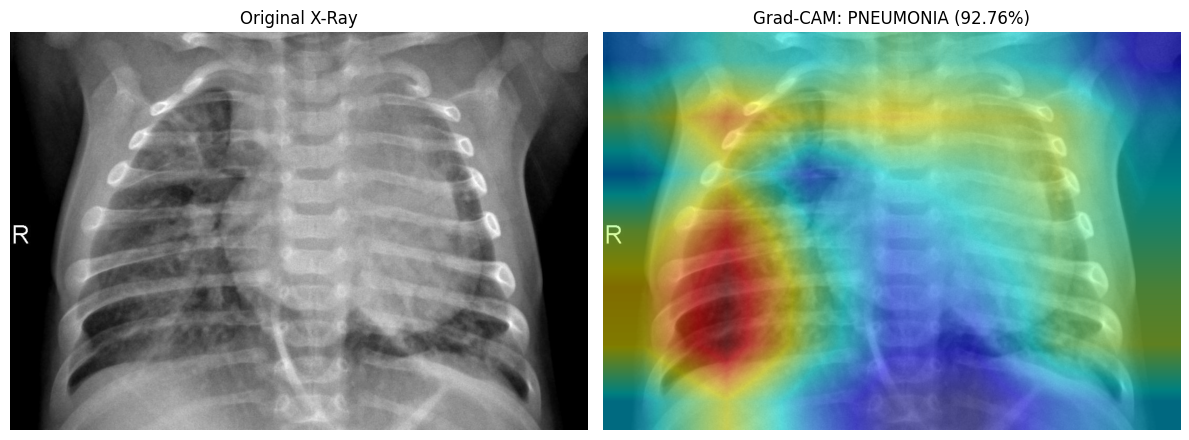

GradCAM overlay saved to ml\reports\gradcam_sample.png


In [6]:
# Cell 5 - Generate Grad-CAM overlay and visualize
REPORT_DIR = pathlib.Path('ml/reports')
REPORT_DIR.mkdir(parents=True, exist_ok=True)

gradcam = GradCAMService(model, target_layer_name='features.norm5')

# Use a fresh tensor clone so the prediction-pass graph doesn't interfere
tensor_for_cam = inference_transform(original).unsqueeze(0).to(device)
overlay = gradcam.generate_overlay(tensor_for_cam, original, class_idx)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original, cmap='gray')
axes[0].set_title('Original X-Ray'); axes[0].axis('off')
axes[1].imshow(overlay)
axes[1].set_title(f'Grad-CAM: {class_names[class_idx]} ({confidence:.2%})')
axes[1].axis('off')
plt.tight_layout()
save_path = REPORT_DIR / 'gradcam_sample.png'
plt.savefig(save_path)
plt.show()
print(f'GradCAM overlay saved to {save_path}')